In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision.transforms import (
    Compose, CenterCrop, RandomResizedCrop,
    Resize, RandomHorizontalFlip, RandomRotation,
    ColorJitter, ToTensor, Normalize
)
from datasets import load_dataset
from transformers import (
    AutoImageProcessor, AutoModelForImageClassification,
    get_cosine_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

In [2]:
SEED = 42
MODEL_ID = "google/vit-base-patch16-224"
OUTPUT_DIR = "vit/outputs/vit_beans_best"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

Device:  cuda


### Real Image Input/Output Demonstration

**Load Dataset**

In [3]:
dataset = load_dataset("AI-Lab-Makerere/beans")

print(dataset)
print("Dataset features: ", dataset["train"].features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})
Dataset features:  {'image_file_path': Value('string'), 'image': Image(mode=None, decode=True), 'labels': ClassLabel(names=['angular_leaf_spot', 'bean_rust', 'healthy'])}


In [4]:
label_names = dataset["train"].features["labels"].names

id2label = {
    index: label for index, label in enumerate(label_names)
}

label2id = {
    label: index for index, label in enumerate(label_names)
}

print("Classes: ")
for index, label in id2label.items():
    print(f"{index} : {label}")

Classes: 
0 : angular_leaf_spot
1 : bean_rust
2 : healthy


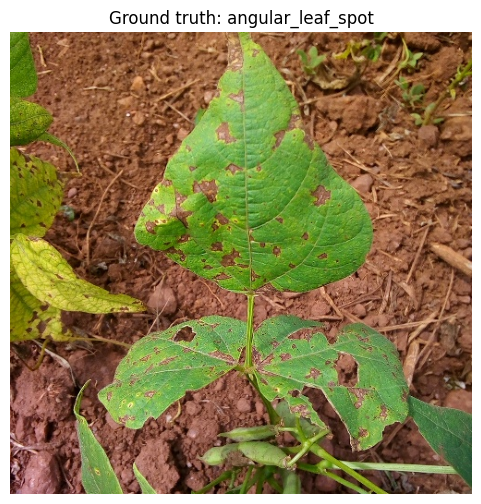

In [5]:
sample = dataset["test"][0]
sample_image = sample["image"].convert("RGB")
sample_label = id2label[sample["labels"]]

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"Ground truth: {sample_label}")
plt.axis("off")
plt.show()

**ImageNet-pretrained ViT inference**

In [6]:
image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)

imagenet_model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)

imagenet_model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [7]:
inputs = image_processor(
    images=sample_image,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.inference_mode():
    outputs = imagenet_model(
        pixel_values=pixel_values,
        output_hidden_states=True,
        return_dict=True
    )    

probabilities = torch.softmax(outputs.logits, dim=-1)
top_probabilities, top_indices = torch.topk(
    probabilities, k=5, dim=-1
)

In [8]:
print("Original image size :", sample_image.size)
print("Pixel tensor        :", tuple(pixel_values.shape))
print("Final hidden state  :", tuple(outputs.hidden_states[-1].shape))
print("CLS representation  :", tuple(outputs.hidden_states[-1][:, 0].shape))
print("Output logits       :", tuple(outputs.logits.shape))

Original image size : (500, 500)
Pixel tensor        : (1, 3, 224, 224)
Final hidden state  : (1, 197, 768)
CLS representation  : (1, 768)
Output logits       : (1, 1000)


In [9]:
print("ImageNet Top-5 predictions:")
for rank, (class_id, score) in enumerate(
    zip(
        top_indices[0].tolist(),
        top_probabilities[0].tolist(),
    ),
    start=1,
):
    label = imagenet_model.config.id2label[class_id]
    print(f"{rank}. {label:<35} {score:.4f}")

ImageNet Top-5 predictions:
1. buckeye, horse chestnut, conker     0.2140
2. cucumber, cuke                      0.0509
3. acorn                               0.0288
4. ear, spike, capitulum               0.0287
5. leaf beetle, chrysomelid            0.0262


### Part B — Dataset Preparation

**Training and evaluation transforms**

In [10]:
image_mean = image_processor.image_mean
image_std = image_processor.image_std

image_size = (
    image_processor.size["height"]
    if "height" in image_processor.size
    else image_processor.size["shortest_edge"]
)

normalize = Normalize(mean=image_mean, std=image_std)

train_transform = Compose([
    RandomResizedCrop(image_size, scale=(0.75, 1.0)),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=10),
    ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    ToTensor(),
    normalize,
])

evaluation_transform = Compose([
    Resize(256),
    CenterCrop(image_size),
    ToTensor(),
    normalize,
])

In [11]:
def apply_train_transform(examples):
    examples["pixel_values"] = [
        train_transform(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

def apply_evaluation_transform(example):
    example["pixel_values"] = [
        evaluation_transform(image.convert("RGB"))
        for image in example["image"]
    ]
    return example

train_dataset = dataset["train"].with_transform(apply_train_transform)
validation_dataset = dataset["validation"].with_transform(apply_evaluation_transform)
test_dataset = dataset["test"].with_transform(apply_evaluation_transform)

**DataLoader**

In [12]:
def collate_fn(batch):
    return {
        "pixel_values" : torch.stack([
            item["pixel_values"] for item in batch
        ]),
        "labels" : torch.tensor([
            item["labels"] for item in batch
        ], dtype=torch.long)
    }

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=device.type == "cuda",
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=device.type == "cuda",
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=device.type == "cuda",
    collate_fn=collate_fn
)

batch = next(iter(train_loader))


print("Images:", batch["pixel_values"].shape)
print("Labels:", batch["labels"].shape)
print("Label values:", batch["labels"][:10])

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Label values: tensor([1, 1, 0, 1, 0, 2, 1, 0, 1, 1])


### ViT Fine-tuning Setup

In [13]:
fine_tune_model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

print("Number of target classes:",fine_tune_model.config.num_labels)
print("Labels:", fine_tune_model.config.id2label)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Number of target classes: 3
Labels: {0: 'angular_leaf_spot', 1: 'bean_rust', 2: 'healthy'}


In [14]:
classifier_name = "classifier"
classifier = fine_tune_model.classifier

encoder_name = "vit.layers"
encoder_stack = fine_tune_model.vit.layers


print("Classifier path:", classifier_name)
print("Classifier:", classifier)

print("Encoder stack path:", encoder_name)
print("Encoder blocks:", len(encoder_stack))

Classifier path: classifier
Classifier: Linear(in_features=768, out_features=3, bias=True)
Encoder stack path: vit.layers
Encoder blocks: 12


**Partial fine-tuning configuration**

In [19]:
UNFREEZE_LAST_BLOCKS = 1

for parameter in fine_tune_model.parameters():
    parameter.requires_grad = False

for paramter in classifier.parameters():
    parameter.requires_grad = True

number_to_unfreeze = min(
    UNFREEZE_LAST_BLOCKS,
    len(encoder_stack)
)
if UNFREEZE_LAST_BLOCKS > 0:
    for block in encoder_stack[-number_to_unfreeze:]:
        for parameter in block.parameters():
            parameter.requires_grad = True

total_parameters = sum(
    parameter.numel()
    for parameter in fine_tune_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in fine_tune_model.parameters()
    if parameter.requires_grad
)

trainable_percentage = (
    100 * trainable_parameters / total_parameters
)

print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Trainable percentage: {trainable_percentage:.2f}%")

Total parameters    : 85,800,963
Trainable parameters: 7,087,875
Trainable percentage: 8.26%


### Before Fine-tuning Evaluation

**Evaluation function**

In [17]:
def evaluate_model(model, data_loader):
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.inference_mode():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device, non_blocking=True
                                                    )
            
            labels = batch["labels"].to(device,
                non_blocking=True,
            )

            outputs = model(
                pixel_values=pixel_values,
                labels=labels,
            )

            total_loss += outputs.loss.item()
            predictions = outputs.logits.argmax(dim=-1)

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_labels.extend(
                labels.cpu().tolist()
            )
    
    average_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "predictions": all_predictions,
        "labels": all_labels,
    }

In [18]:
before_training = evaluate_model(
    fine_tune_model,
    validation_loader,
)

print("BEFORE FINE-TUNING")
print("=" * 35)
print(f"Loss     : {before_training['loss']:.4f}")
print(f"Accuracy : {before_training['accuracy']:.4f}")
print(f"Macro F1 : {before_training['macro_f1']:.4f}")

BEFORE FINE-TUNING
Loss     : 1.1702
Accuracy : 0.2707
Macro F1 : 0.2669


### Part E — Training

**Optimizer and scheduler**

In [20]:
backbone_parameters = [
    parameter
    for parameter in fine_tune_model.vit.parameters()
    if parameter.requires_grad
]

classifier_parameters = [
    parameter
    for parameter in fine_tune_model.classifier.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_parameters,
            "lr": 2e-5,
        },
        {
            "params": classifier_parameters,
            "lr": 5e-4,
        },
    ],
    weight_decay=0.01,
)

In [21]:
EPOCHS = 3
total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)


use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp,
)

print("Epochs:", EPOCHS)
print("Training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)
print("Mixed precision:", use_amp)

Epochs: 3
Training steps: 195
Warmup steps: 19
Mixed precision: True


**Fine-tuning loop**

In [22]:
history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "validation_f1": [],
}

best_validation_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    fine_tune_model.train()
    running_loss = 0.0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        )
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):
            outputs = fine_tune_model(
                pixel_values=pixel_values,
                labels=labels,
            )
            loss = outputs.loss
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_([
                parameter for parameter in fine_tune_model.parameters() if parameter.requires_grad
            ], max_norm=1.0)
            
            
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()

    average_train_loss = (
        running_loss / len(train_loader)
    )

    validation_result = evaluate_model(
        fine_tune_model,
        validation_loader,
    )

    history["train_loss"].append(
        average_train_loss
    )
            
    history["validation_loss"].append(
        validation_result["loss"]
    )

    history["validation_accuracy"].append(
        validation_result["accuracy"]
    )

    history["validation_f1"].append(
        validation_result["macro_f1"]
    )

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Val loss: {validation_result['loss']:.4f} | "
        f"Val accuracy: "
        f"{validation_result['accuracy']:.4f} | "
        f"Val macro F1: "
        f"{validation_result['macro_f1']:.4f}"
    )

    if (
        validation_result["accuracy"]
        > best_validation_accuracy
    ):
        best_validation_accuracy = (
            validation_result["accuracy"]
        )

        fine_tune_model.save_pretrained(
            OUTPUT_DIR
        )

        image_processor.save_pretrained(
            OUTPUT_DIR
        )

        print("Best model saved.")

Epoch 1/3 | Train loss: 1.0293 | Val loss: 0.8276 | Val accuracy: 0.7519 | Val macro F1: 0.7486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.
Epoch 2/3 | Train loss: 0.7340 | Val loss: 0.6435 | Val accuracy: 0.8571 | Val macro F1: 0.8542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.
Epoch 3/3 | Train loss: 0.6311 | Val loss: 0.6167 | Val accuracy: 0.8496 | Val macro F1: 0.8460


### Part F — Training Result

**Learning curves**

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train loss",
)

axes[0].plot(
    epochs,
    history["validation_loss"],
    marker="o",
    label="Validation loss",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    history["validation_accuracy"],
    marker="o",
    label="Validation accuracy",
)

axes[1].plot(
    epochs,
    history["validation_f1"],
    marker="o",
    label="Validation macro F1",
)

axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()